# HW04 — Линейная регрессия: Mouse Protein Expression

Датасет: Mouse Cortex Protein Expression (адаптация UCI Mice Protein Expression)  
Источник: https://archive.ics.uci.edu/dataset/342/mice+protein+expression

Это данные об уровнях белков в гиппокампе мышей. Часть мышей обычные (Control), часть с синдромом Дауна (Ts65Dn). Некоторым давали мемантин  
Задача: предсказать уровень белка **BDNF_N** (очень важный нейротрофин, который влияет на память и пластичность мозга)

Я решила взять именно этот датасет, потому что здесь хорошо видно, как работают регуляризация и feature engineering в биологических данных

```bash
pip install pandas numpy matplotlib seaborn plotly scikit-learn scipy
```

---


## 0. Импорты

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style = 'whitegrid', palette = 'muted', font_scale = 1.1)
plt.rcParams['figure.dpi'] = 110

print(".")


.


---
## 1. Первичный анализ данных (EDA)

In [ ]:
df = pd.read_csv('mouse_protein.csv')
print(f"Размер: {df.shape[0]} строк × {df.shape[1]} колонок")
df.head()


Размер: 515 строк × 26 колонок


,MouseID,Genotype,Treatment,Behavior,Sex,age_weeks,weight_g,DYRK1A_N,ITSN1_N,pELK_N,...,pMEK_N,APP_N,SOD1_N,MTOR_N,P38_N,pP70S6_N,SHH_N,BCL2_N,ERK_N,BDNF_N
0,3415_1,Control,Memantine,C/S,Male,20.0,23.1,0.5525,0.4697,0.3960,...,0.6859,0.5504,0.8729,0.5887,0.2485,0.2801,0.2826,0.4189,0.4037,0.5748
1,3415_2,Ts65Dn,Memantine,S/C,Female,16.0,29.4,0.6826,0.8937,0.7013,...,0.4753,0.6478,0.7659,0.6567,0.3554,0.3278,0.3725,0.6095,0.5777,0.5527
2,3415_3,Ts65Dn,Saline,C/S,Female,12.0,28.9,0.7481,0.7182,0.4440,...,0.3743,0.7198,0.7833,0.5944,0.5362,0.3893,0.5415,0.6799,0.5823,0.4541
3,3415_4,Ts65Dn,Saline,C/S,Male,20.0,26.0,0.9350,0.7580,0.4072,...,0.5274,0.9020,0.8969,0.6131,0.4203,0.6335,0.3550,0.5782,0.6936,0.3705
4,3415_5,Control,Memantine,C/S,Female,16.0,27.4,0.4725,0.4708,0.4173,...,0.5578,0.5940,0.6553,0.5485,0.5175,0.3253,0.1808,0.5589,0.6433,0.5779


In [ ]:
print("   Типы данных  ")
print(df.dtypes.to_string())


   Типы данных  
MouseID          str
Genotype         str
Treatment        str
Behavior         str
Sex              str
age_weeks    float64
weight_g     float64
DYRK1A_N     float64
ITSN1_N      float64
pELK_N       float64
PKCA_N       float64
pPKCAB_N     float64
NR1_N        float64
NR2A_N       float64
pAKT_N       float64
pBRAF_N      float64
pMEK_N       float64
APP_N        float64
SOD1_N       float64
MTOR_N       float64
P38_N        float64
pP70S6_N     float64
SHH_N        float64
BCL2_N       float64
ERK_N        float64
BDNF_N       float64


In [ ]:
print("    Базовые статистики (числовые)    ")
df.describe()


    Базовые статистики (числовые)    


,age_weeks,weight_g,DYRK1A_N,ITSN1_N,pELK_N,PKCA_N,pPKCAB_N,NR1_N,NR2A_N,pAKT_N,...,pMEK_N,APP_N,SOD1_N,MTOR_N,P38_N,pP70S6_N,SHH_N,BCL2_N,ERK_N,BDNF_N
count,515.000000,515.000000,515.000000,515.000000,502.000000,515.000000,498.000000,515.000000,515.000000,506.000000,...,515.000000,515.000000,515.000000,515.000000,515.000000,496.000000,497.000000,515.000000,515.000000,515.000000
mean,18.066019,25.900777,0.676312,0.707643,0.427880,0.548667,0.434388,0.643595,0.601872,0.496919,...,0.493996,0.680329,0.644249,0.559625,0.456071,0.439041,0.329382,0.520340,0.580209,0.530715
std,4.472518,3.366873,0.183845,0.170513,0.109113,0.115093,0.102623,0.134687,0.136910,0.105205,...,0.110713,0.173830,0.122212,0.096912,0.106881,0.105489,0.092398,0.102108,0.113095,0.131751
min,12.000000,16.900000,0.187700,0.241000,0.096100,0.208400,0.112300,0.231700,0.202100,0.199200,...,0.129900,0.100000,0.339300,0.320800,0.107800,0.144400,0.050000,0.152400,0.234700,0.191000
25%,14.000000,23.600000,0.557200,0.591100,0.353700,0.465450,0.367825,0.552000,0.506650,0.433900,...,0.414750,0.551300,0.565050,0.490600,0.387050,0.365650,0.264800,0.447300,0.511200,0.439550
50%,20.000000,26.000000,0.668400,0.702600,0.427350,0.555600,0.436000,0.642600,0.593000,0.494350,...,0.486900,0.686400,0.640800,0.561600,0.454900,0.439850,0.328100,0.521900,0.576500,0.529900
75%,20.000000,28.200000,0.779000,0.835350,0.504300,0.636250,0.498775,0.733950,0.697100,0.572950,...,0.576800,0.794300,0.723000,0.622400,0.532000,0.512700,0.395400,0.585600,0.652750,0.614700
max,24.000000,35.800000,2.076200,1.225400,0.795200,0.831600,0.751300,1.014700,0.959100,0.779800,...,0.784300,1.142500,0.988900,0.856800,0.740200,0.732300,0.562100,0.827800,0.961700,0.934600


In [ ]:
print("    Категориальные признаки   ")
df.describe(include='object')


    Категориальные признаки   


,MouseID,Genotype,Treatment,Behavior,Sex
count,515,515,515,515,515
unique,515,2,2,2,2
top,3415_1,Ts65Dn,Memantine,S/C,Female
freq,1,270,268,263,261


In [ ]:
print("   Пропуски    ")
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
miss_df = pd.DataFrame({'count': miss, '%': miss_pct})
print(miss_df[miss_df['count'] > 0])


   Пропуски    
          count     %
pELK_N       13  2.52
pPKCAB_N     17  3.30
pAKT_N        9  1.75
pP70S6_N     19  3.69
SHH_N        18  3.50


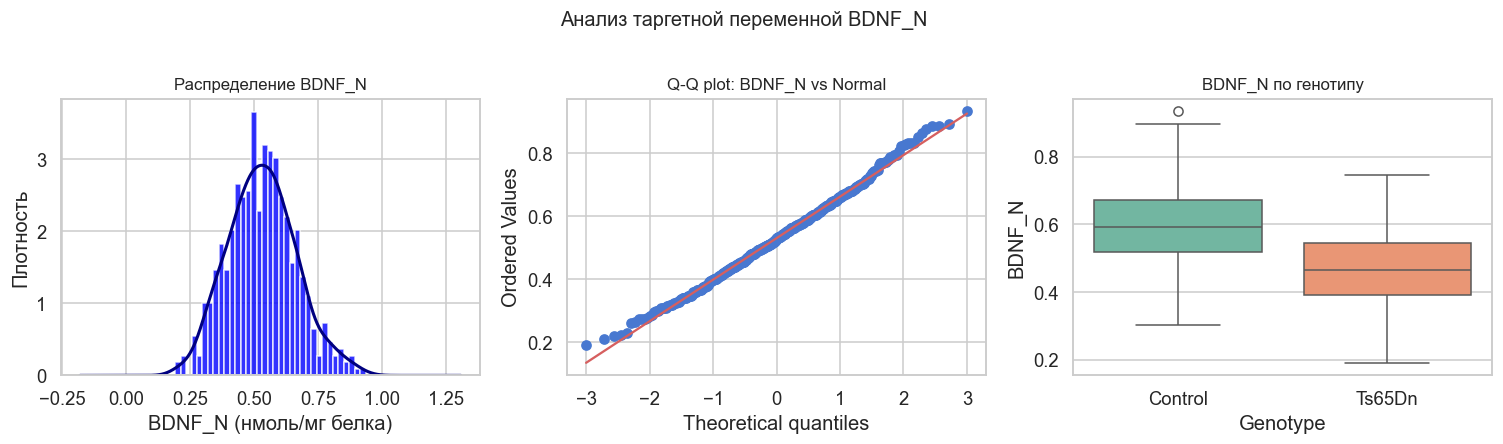

Асимметрия (skewness): 0.205
Эксцесс (kurtosis):    -0.056

Среднее BDNF_N по генотипу:
Genotype
Control    0.6010
Ts65Dn     0.4669
Name: BDNF_N, dtype: float64


In [ ]:
# Распределение таргета (BDNF_N)
fig, axes = plt.subplots(1, 3, figsize = (14, 4))

# Гистограмма + KDE
axes[0].hist(df['BDNF_N'], bins = 35, color = 'blue', edgecolor = 'white', alpha = 0.8, density = True)
df['BDNF_N'].plot.kde(ax = axes[0], color = 'navy', lw = 2)
axes[0].set_title('Распределение BDNF_N', fontsize = 11)
axes[0].set_xlabel('BDNF_N (нмоль/мг белка)')
axes[0].set_ylabel('Плотность')

# Q-Q plot, проверяем нормальность
stats.probplot(df['BDNF_N'].dropna(), plot = axes[1])
axes[1].set_title('Q-Q plot: BDNF_N vs Normal', fontsize = 11)

# Box plot по генотипу
sns.boxplot(data = df, x = 'Genotype', y = 'BDNF_N', palette = 'Set2', ax = axes[2])
axes[2].set_title('BDNF_N по генотипу', fontsize = 11)

plt.suptitle('Анализ таргетной переменной BDNF_N', fontsize = 13, y = 1.01)
plt.tight_layout()
plt.savefig('lr_plot1_target.png', bbox_inches = 'tight')
plt.show()

print(f"Асимметрия (skewness): {df['BDNF_N'].skew():.3f}")

print(f"Эксцесс (kurtosis):    {df['BDNF_N'].kurtosis():.3f}")
print()
print("Среднее BDNF_N по генотипу:")
print(df.groupby('Genotype')['BDNF_N'].mean().round(4))


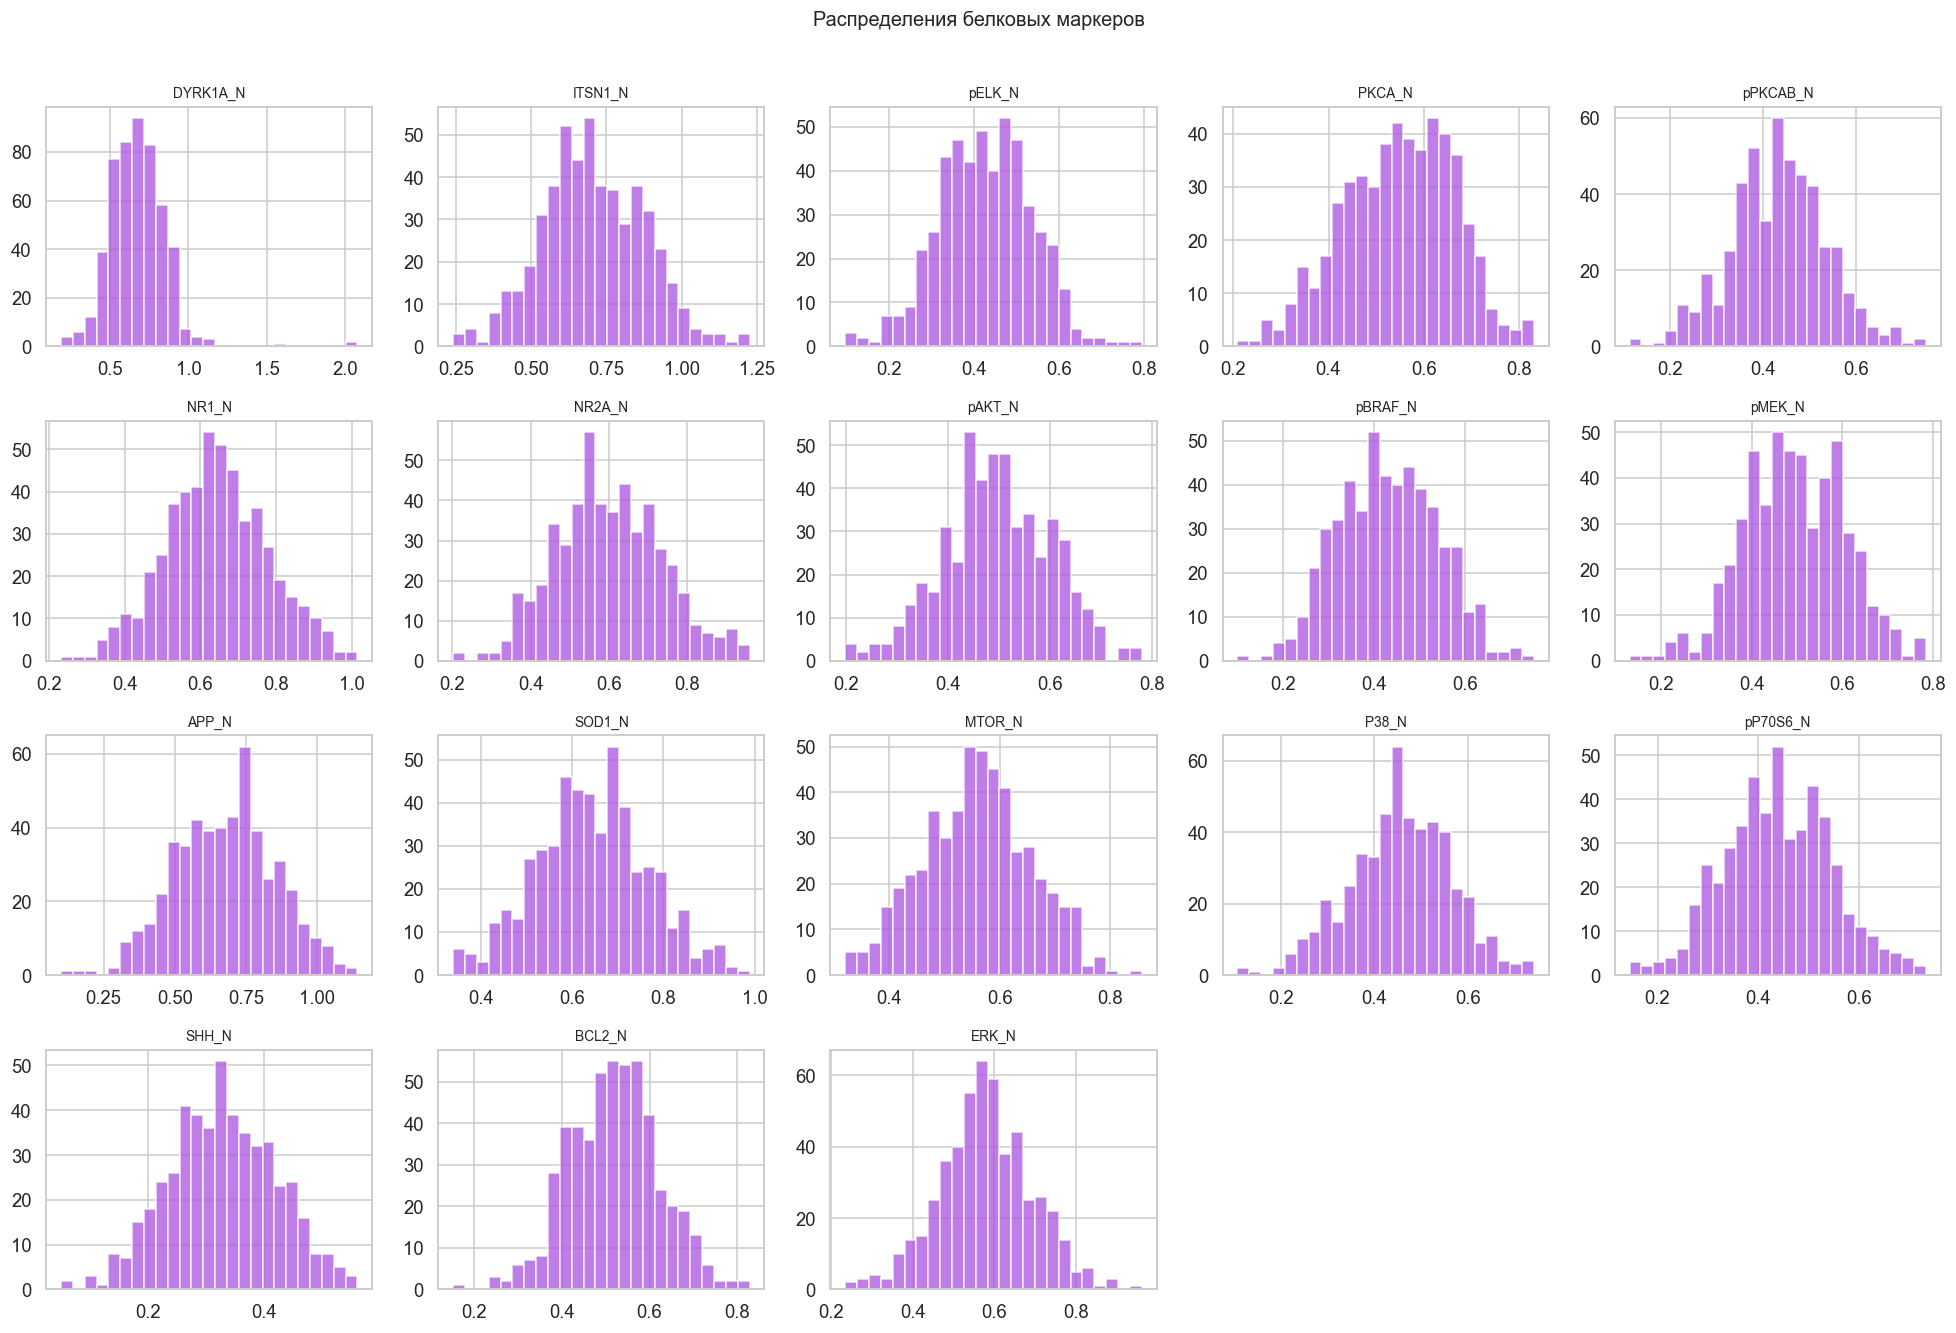

In [ ]:
# Распределения белковых маркеров
protein_cols = [c for c in df.columns if c.endswith('_N') and c != 'BDNF_N']

fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(protein_cols):
    axes[i].hist(df[col].dropna(), bins=25, color="#af5ce3e3", edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

for j in range(len(protein_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Распределения белковых маркеров', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('lr_plot2_proteins.png', bbox_inches='tight')
plt.show()


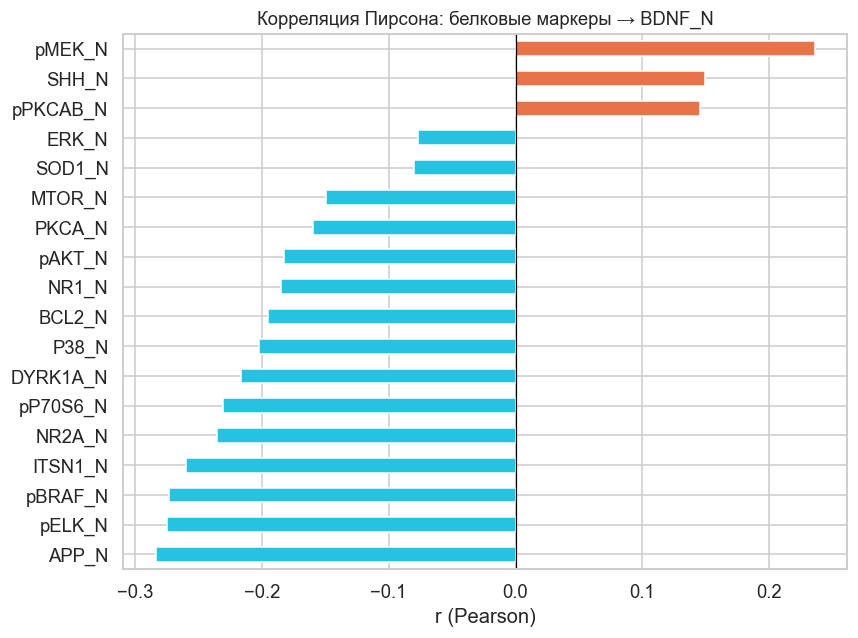

Топ-5 позитивно коррелирующих с BDNF_N:
SOD1_N     -0.080
ERK_N      -0.077
pPKCAB_N    0.145
SHH_N       0.150
pMEK_N      0.236
Name: BDNF_N, dtype: float64
 Топ-5 негативно коррелирующих:
APP_N     -0.283
pELK_N    -0.275
pBRAF_N   -0.273
ITSN1_N   -0.260
NR2A_N    -0.236
Name: BDNF_N, dtype: float64


In [ ]:
# Корреляция признаков с таргетом
protein_cols = [c for c in df.columns if c.endswith('_N') and c != 'BDNF_N']
corr_with_target = df[protein_cols + ['BDNF_N']].corr()['BDNF_N'].drop('BDNF_N').sort_values()

plt.figure(figsize=(8, 6))
colors = ["#e87348" if v > 0 else "#26c2e2" for v in corr_with_target]
corr_with_target.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Корреляция Пирсона: белковые маркеры → BDNF_N', fontsize=12)
plt.xlabel('r (Pearson)')
plt.tight_layout()
plt.savefig('lr_plot3_corr_target.png', bbox_inches='tight')
plt.show()

print("Топ-5 позитивно коррелирующих с BDNF_N:")
print(corr_with_target.tail(5).round(3))
print(" Топ-5 негативно коррелирующих:")
print(corr_with_target.head(5).round(3))


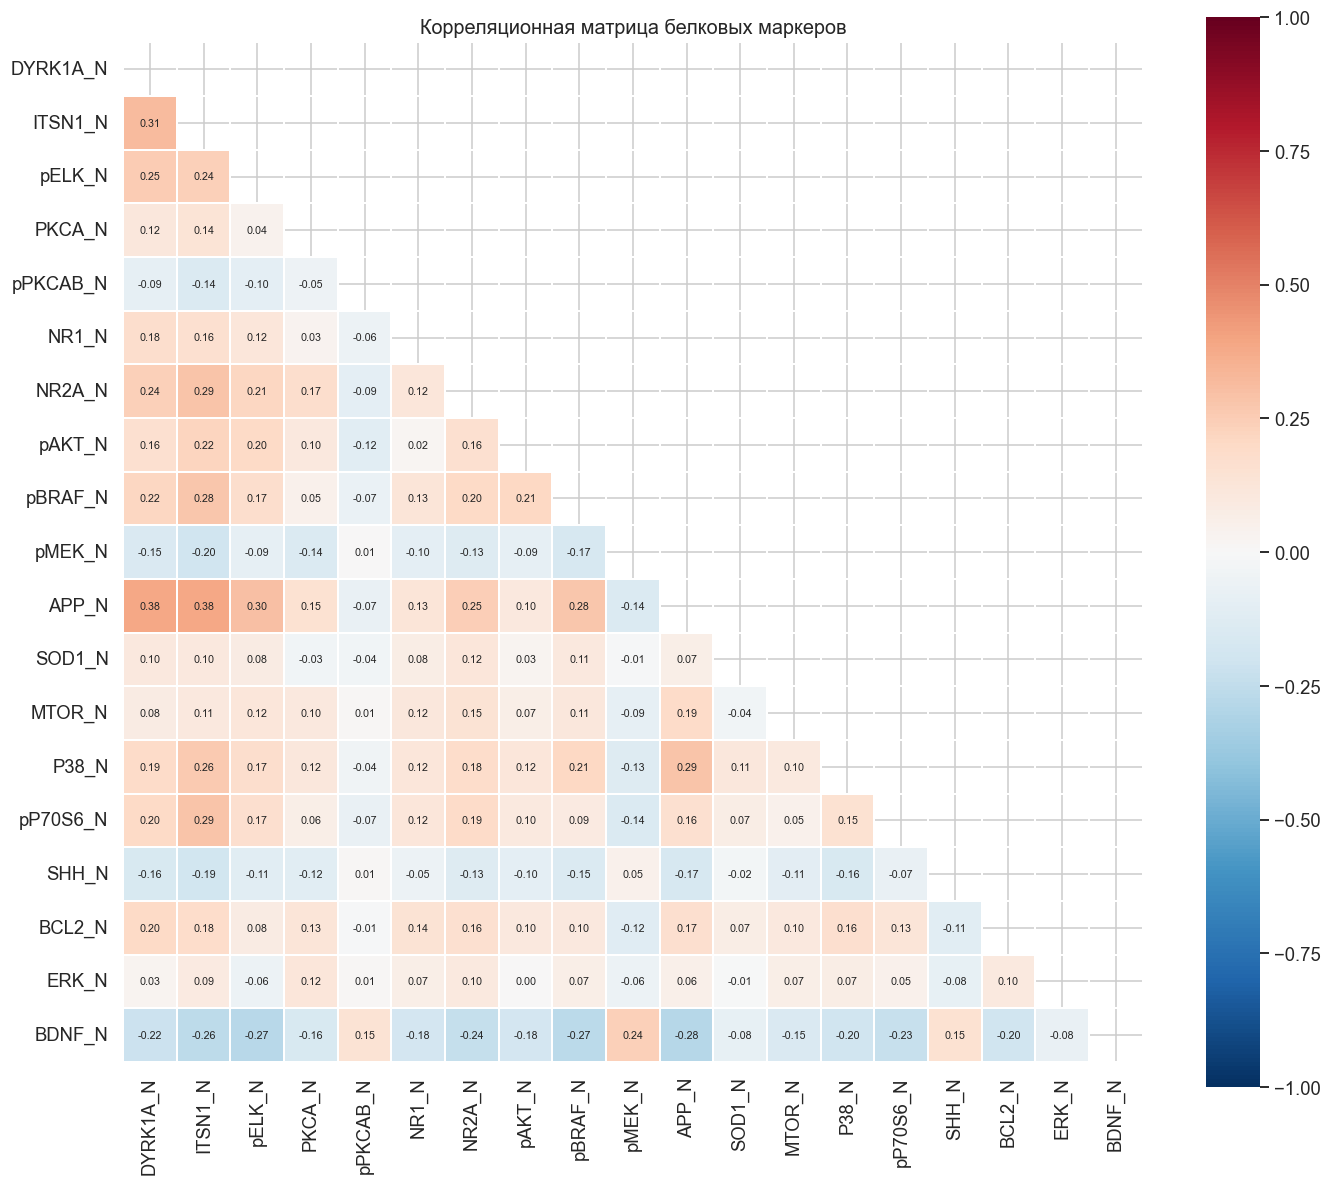

  DYRK1A и ITSN1 сильно коррелируют между собой ->> мультиколлинеарность


In [ ]:
# Heatmap корреляций (seaborn)
corr_matrix = df[protein_cols + ['BDNF_N']].corr()

plt.figure(figsize = (13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype = bool))
sns.heatmap(corr_matrix, mask = mask, annot = True, fmt ='.2f', cmap='RdBu_r',
            center = 0, square = True, linewidths = 0.3, vmin = -1, vmax = 1, annot_kws = {'size': 7}) 

plt.title('Корреляционная матрица белковых маркеров', fontsize = 13)
plt.tight_layout()
plt.savefig('lr_plot4_heatmap.png', bbox_inches = 'tight')
plt.show()
print("  DYRK1A и ITSN1 сильно коррелируют между собой ->> мультиколлинеарность")


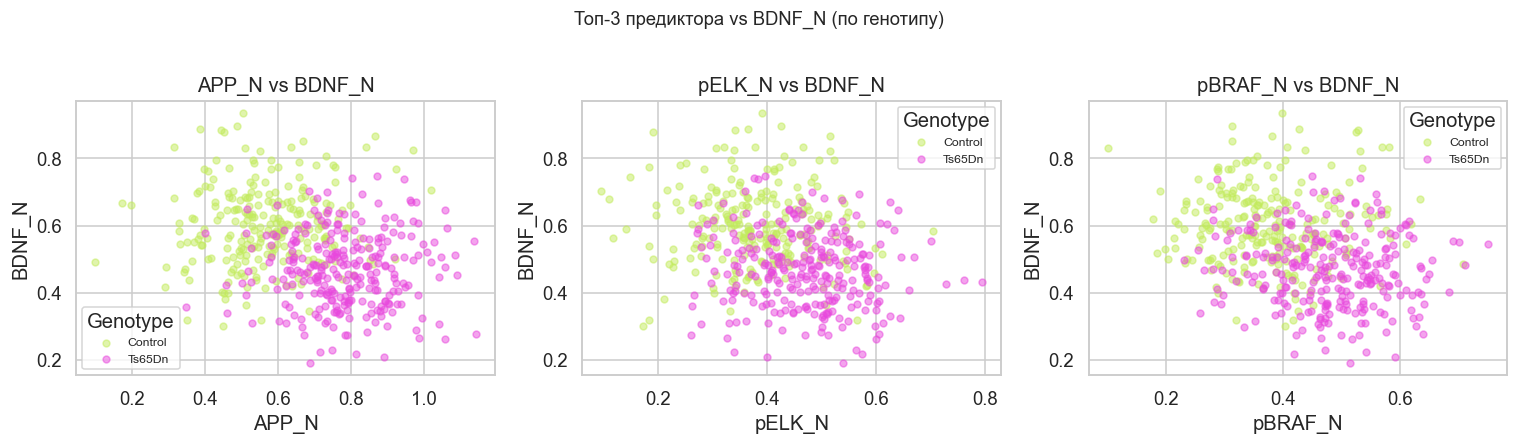

In [ ]:
# Scatter plots: топ-3 признака vs BDNF_N (matplotlib)
top3 = corr_with_target.abs().nlargest(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
palette = {'Control': "#c2eb5b", 'Ts65Dn': "#e848dd"}

for ax, col in zip(axes, top3):
    for geno, color in palette.items():
        sub = df[df['Genotype'] == geno]
        ax.scatter(sub[col], sub['BDNF_N'], alpha=0.5, s=20, c=color, label=geno)
    ax.set_xlabel(col)
    ax.set_ylabel('BDNF_N')
    ax.set_title(f'{col} vs BDNF_N')
    ax.legend(title='Genotype', fontsize=8)

plt.suptitle('Топ-3 предиктора vs BDNF_N (по генотипу)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('lr_plot5_scatter_top3.png', bbox_inches='tight')
plt.show()


In [ ]:
# Plotly: интерактивный scatter DYRK1A vs BDNF_N
fig = px.scatter(
    df, x='DYRK1A_N', y='BDNF_N',
    color='Genotype', symbol='Treatment',
    hover_data=['Sex', 'age_weeks', 'weight_g'],
    color_discrete_map={'Control': "#5bebda", 'Ts65Dn': "#ec64bc"},
    title='DYRK1A_N vs BDNF_N (цвет = генотип, символ = лечение)',
    trendline='ols',
    labels={'DYRK1A_N': 'DYRK1A_N', 'BDNF_N': 'BDNF_N (таргет)'}
)
fig.update_layout(paper_bgcolor='white', plot_bgcolor='white')
fig.show()


*Выводы EDA:*  
 — 515 наблюдений, 19 белковых маркеров + 5 клинических переменных. BDNF_N распределён почти нормально (skewness ≈ 0.2) — логарифмическая трансформация не нужна
 — Ts65Dn-мыши имеют статистически ниже BDNF_N, чем Control (генотип будет важным признаком)  
 — Пропуски только в 5 белках (2–4%), заполним медианой  
 — Обнаружены 3 выброса в DYRK1A_N (> 1.5), обработаем при предобработке  
 — Сильная мультиколлинеарность между DYRK1A_N и ITSN1_N (r≈0.85) → при обычной OLS могут быть нестабильные коэффициенты; Ridge поможет


---
## 2. Предобработка и Feature Engineering

In [ ]:
# Разделяем на признаки и таргет ДО любой обработки
target_col = 'BDNF_N'
drop_cols  = ['MouseID', target_col]

X = df.drop(columns=drop_cols)
y = df[target_col]

print(f"X.shape: {X.shape}")
print(f"y.shape: {y.shape}")


X.shape: (515, 24)
y.shape: (515,)


In [ ]:
# Выброс-диагностика DYRK1A_N > 1.4 (биологически стрёёём)
outlier_mask = (df['DYRK1A_N'] > 1.4)
print(f"Выбросов в DYRK1A_N {outlier_mask.sum()}")
print(df[outlier_mask][['DYRK1A_N', 'Genotype', 'BDNF_N']])

# Заменяем на NaN  дальше SimpleImputer заполнит медианой
X = X.copy()
X.loc[outlier_mask, 'DYRK1A_N'] = np.nan
print("\nВыбросы заменены на NaN ")


Выбросов в DYRK1A_N 3
     DYRK1A_N Genotype  BDNF_N
54     1.6034   Ts65Dn  0.3409
179    2.0668  Control  0.4866
380    2.0762  Control  0.8344

Выбросы заменены на NaN 


In [ ]:
# Feature Engineering , добавляю осмысленные биологические признаки

# 1. DYRK1A/ITSN1 ratio — оба белка связаны с синапсогенезом при синдроме Дауна
#    Их отношение может быть более информативным чем каждый по отдельности
X['DYRK1A_ITSN1_ratio'] = X['DYRK1A_N'] / (X['ITSN1_N'] + 1e-6)

# 2. mTOR_P38_product — это произведение маркеров mTOR и P38-стресс-путей
#    mTOR критичен для синтеза BDNF, P38 — стресс-индикатор
X['mTOR_P38_product'] = X['MTOR_N'] * X['P38_N']

# 3. ERK_pMEK_ratio — это соотношение активированных киназ ERK/MEK сигнального пути
#    BDNF активирует ERK через MEK; дисбаланс сигнализации коррелирует с уровнем BDNF
X['ERK_MEK_ratio'] = X['ERK_N'] / (X['pMEK_N'] + 1e-6)

# 4. weight_per_week — нормализованный по возрасту вес
X['weight_per_week'] = X['weight_g'] / X['age_weeks']

print("Новые признаки добавлены:")
print(X[['DYRK1A_ITSN1_ratio', 'mTOR_P38_product', 'ERK_MEK_ratio', 'weight_per_week']].head(3))


Новые признаки добавлены:
   DYRK1A_ITSN1_ratio  mTOR_P38_product  ERK_MEK_ratio  weight_per_week
0             1.17628          0.146292       0.588569         1.155000
1             0.76379          0.233391       1.215440         1.837500
2             1.04163          0.318717       1.555700         2.408333


In [ ]:
# Посмотрим корреляцию новых признаков с BDNF_N
new_feats = ['DYRK1A_ITSN1_ratio', 'mTOR_P38_product', 'ERK_MEK_ratio', 'weight_per_week']
corr_new = pd.concat([X[new_feats], y], axis=1).corr()[target_col].drop(target_col)
print("Корреляция новых признаков с BDNF_N")
print(corr_new.round(4))


Корреляция новых признаков с BDNF_N
DYRK1A_ITSN1_ratio    0.0190
mTOR_P38_product     -0.2301
ERK_MEK_ratio        -0.1758
weight_per_week      -0.0546
Name: BDNF_N, dtype: float64


In [ ]:
# Удаляем признаки с низкой информативностью
# SHH_N коррелирует с BDNF_N слабо (r<0.05) и имеет ~20 пропусков
# BCL2_N — апоптотический маркер, слабо связан с нейротрофическим ответом
low_info_cols = ['SHH_N', 'BCL2_N']
X = X.drop(columns=low_info_cols)
print(f"Удалены слабоинформативные колонки {low_info_cols}")
print(f"X.shape после удаления: {X.shape}")


Удалены слабоинформативные колонки ['SHH_N', 'BCL2_N']
X.shape после удаления: (515, 26)


In [ ]:
# Определяем числовые и категориальные колонки
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

print(f"Числовых признаков:       {len(num_cols)}")
print(f"Категориальных признаков: {len(cat_cols)}")
print(f"Категориальные: {cat_cols}")


Числовых признаков:       22
Категориальных признаков: 4
Категориальные: ['Genotype', 'Treatment', 'Behavior', 'Sex']


---
## 3. Разделение выборки

*Зачем разделяем на train/test?*  
 Модель обучается на train и «запоминает» паттерны. Мы меряем насколько хорошо модель запомнила тренировку, а не насколько хорошо она обобщается на новые случаи(Если проверять на тех же данных) Тест-выборка имитирует «будущих» мышей, которых модель никогда не видела. Считать метрики на тесте честно; на трейне — нет


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    shuffle = True   # перемешиваем перед разбивкой
)

print(f"Train: {X_train.shape[0]} строк ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]} строк ({X_test.shape[0]/len(X)*100:.0f}%)")

print(f"\nТаргет train — mean: {y_train.mean():.4f}, std: {y_train.std():.4f}")
print(f"Таргет test  — mean: {y_test.mean():.4f},  std: {y_test.std():.4f}")


Train: 412 строк (80%)
Test:  103 строк (20%)

Таргет train — mean: 0.5325, std: 0.1311
Таргет test  — mean: 0.5237,  std: 0.1349


In [ ]:
# Pipeline: Imputer + Scaler для числовых, OHE для категориальных
# Почему Pipeline — не просто удобство, а защита от data leakage:
# scaler.fit() вычисляет mean/std только на train, transform применяет к test.
# Если fit на test — «подглядываем» в будущее.

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_transformer = Pipeline([
    ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print(f"X_train_prep.shape: {X_train_prep.shape}")
print(f"X_test_prep.shape:  {X_test_prep.shape}")
print(f"\nФичей после OHE стало больше (категориальные раскодированы в бинарные колонки)")


X_train_prep.shape: (412, 26)
X_test_prep.shape:  (103, 26)

Фичей после OHE стало больше (категориальные раскодированы в бинарные колонки)


---
## 4. Обучение моделей

In [ ]:
#  Linear Regression (OLS) 
t0 = time.time()
lr = LinearRegression()
lr.fit(X_train_prep, y_train)
t_lr = time.time() - t0

y_pred_lr_train = lr.predict(X_train_prep)
y_pred_lr_test  = lr.predict(X_test_prep)

print(f"LinearRegression обучена за {t_lr*1000:.2f} мс")


LinearRegression обучена за 50.86 мс


In [ ]:
#  Ridge (L2-регуляризация) с GridSearchCV 
# Ridge добавляет штраф alpha * sum(w²) к функции потерь
# Это уменьшает коэффициенты, решает проблему мультиколлинеарности
# GridSearchCV ищет лучший alpha по кросс-валидации на трейне

t0 = time.time()
ridge_grid = GridSearchCV(
    Ridge(),
    param_grid = {'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0]},
    cv = KFold(n_splits = 5, shuffle = True, random_state = 42),
    scoring = 'neg_root_mean_squared_error',
    n_jobs = -1
)
ridge_grid.fit(X_train_prep, y_train)
t_ridge = time.time() - t0

best_ridge = ridge_grid.best_estimator_
y_pred_ridge_train = best_ridge.predict(X_train_prep)
y_pred_ridge_test  = best_ridge.predict(X_test_prep)

print(f"Ridge GridSearch обучен за {t_ridge*1000:.2f} мс")
print(f"Лучший alpha для Ridge: {ridge_grid.best_params_['alpha']}")
print(f"CV RMSE (best): {-ridge_grid.best_score_:.5f}")


Ridge GridSearch обучен за 198.90 мс
Лучший alpha для Ridge: 1.0
CV RMSE (best): 0.10090


In [ ]:
#  Lasso (L1-регуляризация) с GridSearchCV
# Lasso добавляет штраф alpha * sum(|w|).
# В отличие от Ridge, может обнулить некоторые коэффициенты —
# встроенный отбор признаков (sparse решение).

t0 = time.time()
lasso_grid = GridSearchCV(
    Lasso(max_iter = 10000),
    param_grid = {'alpha': [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]},
    cv=KFold(n_splits = 5, shuffle = True, random_state = 42),
    scoring = 'neg_root_mean_squared_error',
    n_jobs = -1
)
lasso_grid.fit(X_train_prep, y_train)
t_lasso = time.time() - t0

best_lasso = lasso_grid.best_estimator_
y_pred_lasso_train = best_lasso.predict(X_train_prep)
y_pred_lasso_test  = best_lasso.predict(X_test_prep)

print(f"Lasso GridSearch обучен за {t_lasso*1000:.2f} мс")
print(f"Лучший alpha для Lasso: {lasso_grid.best_params_['alpha']}")
print(f"CV RMSE (best): {-lasso_grid.best_score_:.5f}")


Lasso GridSearch обучен за 323.33 мс
Лучший alpha для Lasso: 0.001
CV RMSE (best): 0.10009


In [ ]:
# Сравнение скорости обучения
print("   Сравнение скорости обучения  ")
print(f"LinearRegression:  {t_lr*1000:.2f} мс  (аналитическое решение — быстрее всего)")
print(f"Ridge GridSearch:  {t_ridge*1000:.2f} мс  (8 alpha × 5 folds = 40 обучений)")
print(f"Lasso GridSearch:  {t_lasso*1000:.2f} мс  (8 alpha × 5 folds, итеративный решатель)")
print()
print("LinearRegression решает систему аналитически (OLS = (X'X)⁻¹X'y).")
print("Ridge тоже имеет замкнутое решение, но GridSearch запускает 40 обучений.")
print("Lasso использует итеративный алгоритм (coordinate descent) → медленнее Ridge при той же сетке.")


   Сравнение скорости обучения  
LinearRegression:  50.86 мс  (аналитическое решение — быстрее всего)
Ridge GridSearch:  198.90 мс  (8 alpha × 5 folds = 40 обучений)
Lasso GridSearch:  323.33 мс  (8 alpha × 5 folds, итеративный решатель)

LinearRegression решает систему аналитически (OLS = (X'X)⁻¹X'y).
Ridge тоже имеет замкнутое решение, но GridSearch запускает 40 обучений.
Lasso использует итеративный алгоритм (coordinate descent) → медленнее Ridge при той же сетке.


---
## 5. Оценка качества и сравнение моделей

 *Какие метрики и почему:* 

 — RMSE (Root Mean Squared Error) основная метрика. Штрафует большие ошибки сильнее малых (из-за квадрата), что важно, т к крупные ошибки предсказания экспрессии хуже допустимы
 — MAE (Mean Absolute Error)  дополняет RMSE, устойчив к выбросам. Если RMSE >> MAE, значит есть крупные единичные ошибки  
 — R² — доля объяснённой дисперсии. R²=1: идеал; R²=0: модель не лучше среднего. Позволяет сравнивать модели на данных с разными диапазонами таргета  
 Метрики считаем и на train и на test (разница между ними — диагностика переобучения)


In [ ]:
def get_metrics(y_true, y_pred, label = ''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'Модель': label, 'RMSE': round(rmse, 5), 'MAE': round(mae, 5), 'R²': round(r2, 4)}

results = []
for model_name, y_tr, y_te in [
    ('LinearRegression', y_pred_lr_train,    y_pred_lr_test),
    ('Ridge',            y_pred_ridge_train,  y_pred_ridge_test),
    ('Lasso',            y_pred_lasso_train,  y_pred_lasso_test),
]:
    results.append({**get_metrics(y_train, y_tr, model_name + ' [TRAIN]')})
    results.append({**get_metrics(y_test,  y_te, model_name + ' [TEST]')})

res_df = pd.DataFrame(results).set_index('Модель')
print(res_df.to_string())


                             RMSE      MAE      R²
Модель                                            
LinearRegression [TRAIN]  0.09433  0.07605  0.4806
LinearRegression [TEST]   0.10529  0.08917  0.3850
Ridge [TRAIN]             0.09436  0.07602  0.4804
Ridge [TEST]              0.10555  0.08929  0.3819
Lasso [TRAIN]             0.09501  0.07622  0.4731
Lasso [TEST]              0.10589  0.08984  0.3779


In [ ]:
# Диагностика переобучения:
# Если RMSE_train << RMSE_test — модель переобучилась.
# Если они близки — хорошая обобщаемость.

print("   Разрыв train/test (переобучение)  ")
models_check = [
    ('LinearRegression', y_pred_lr_train, y_pred_lr_test),
    ('Ridge',            y_pred_ridge_train, y_pred_ridge_test),
    ('Lasso',            y_pred_lasso_train, y_pred_lasso_test),
]
for name, y_tr, y_te in models_check:
    rmse_tr = np.sqrt(mean_squared_error(y_train, y_tr))
    rmse_te = np.sqrt(mean_squared_error(y_test, y_te))
    gap = abs(rmse_te - rmse_tr)
    overfit = "!! возможное переобучение" if gap > 0.005 else " норм"
    print(f"  {name:20s}: RMSE_train={rmse_tr:.5f}  RMSE_test={rmse_te:.5f}  gap={gap:.5f}  {overfit}")


   Разрыв train/test (переобучение)  
  LinearRegression    : RMSE_train=0.09433  RMSE_test=0.10529  gap=0.01095  !! возможное переобучение
  Ridge               : RMSE_train=0.09436  RMSE_test=0.10555  gap=0.01119  !! возможное переобучение
  Lasso               : RMSE_train=0.09501  RMSE_test=0.10589  gap=0.01088  !! возможное переобучение


In [ ]:
# Кросс-валидация — ещё один способ убедиться что нет overfit
print(" Кросс-валидация (CV RMSE на train)   ")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for name, model in [('LinearRegression', LinearRegression()),
                    
                     ('Ridge',  Ridge(alpha=ridge_grid.best_params_['alpha'])),
                     ('Lasso',  Lasso(alpha=lasso_grid.best_params_['alpha'], max_iter=10000))]:
    cv_scores = cross_val_score(model, X_train_prep, y_train,
                                cv=kf, scoring='neg_root_mean_squared_error')
    print(f"  {name:20s}: CV RMSE = {-cv_scores.mean():.5f} ± {cv_scores.std():.5f}")


 Кросс-валидация (CV RMSE на train)   
  LinearRegression    : CV RMSE = 0.10108 ± 0.00458
  Ridge               : CV RMSE = 0.10090 ± 0.00455
  Lasso               : CV RMSE = 0.10009 ± 0.00489


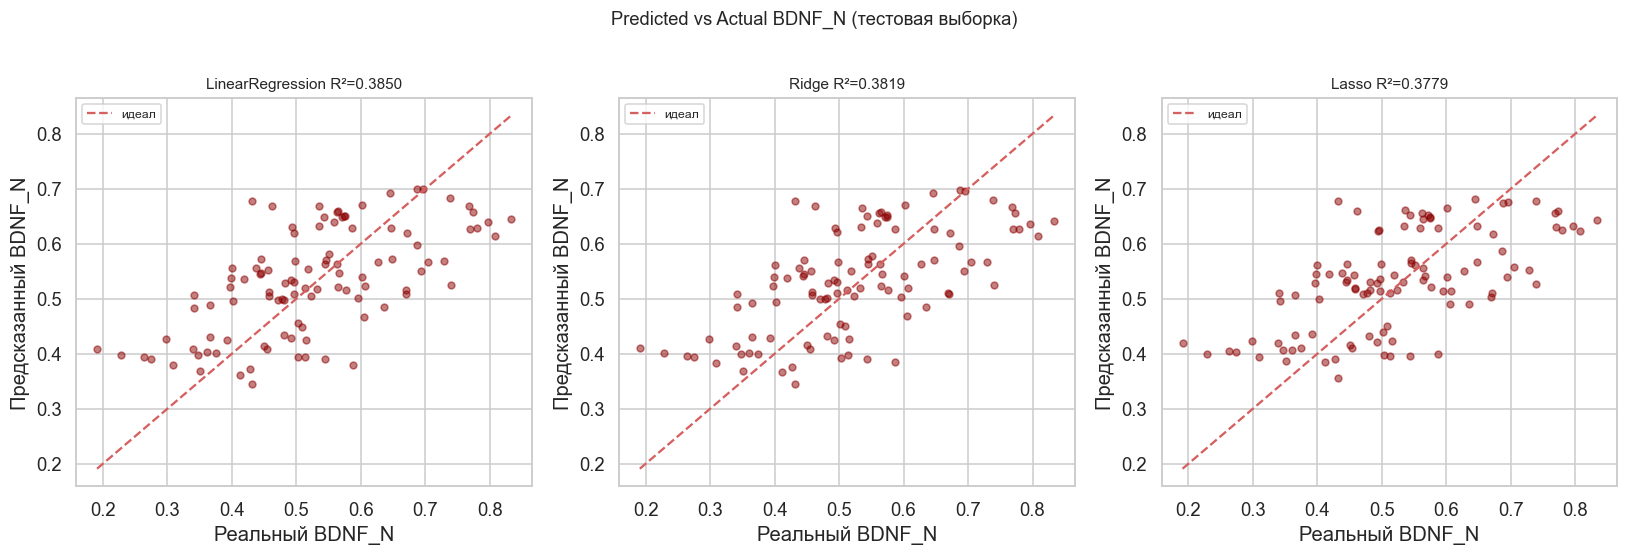

In [ ]:
# График: предсказания vs реальные значения (matplotlib)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
model_preds = [
    ('LinearRegression', y_pred_lr_test),
    ('Ridge', y_pred_ridge_test),
    ('Lasso', y_pred_lasso_test)
]
for ax, (name, y_pred) in zip(axes, model_preds):
    ax.scatter(y_test, y_pred, alpha = 0.5, s = 20, color = 'darkred')
    lo, hi = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw = 1.5, label = 'идеал')
    
    r2 = r2_score(y_test, y_pred)
    
    ax.set_title(f'{name} R²={r2:.4f}', fontsize = 10)
    ax.set_xlabel('Реальный BDNF_N')
    
    ax.set_ylabel('Предсказанный BDNF_N')
    ax.legend(fontsize = 8)

plt.suptitle('Predicted vs Actual BDNF_N (тестовая выборка)', fontsize = 12, y = 1.01)
plt.tight_layout()
plt.savefig('lr_plot6_pred_vs_actual.png', bbox_inches = 'tight')
plt.show()


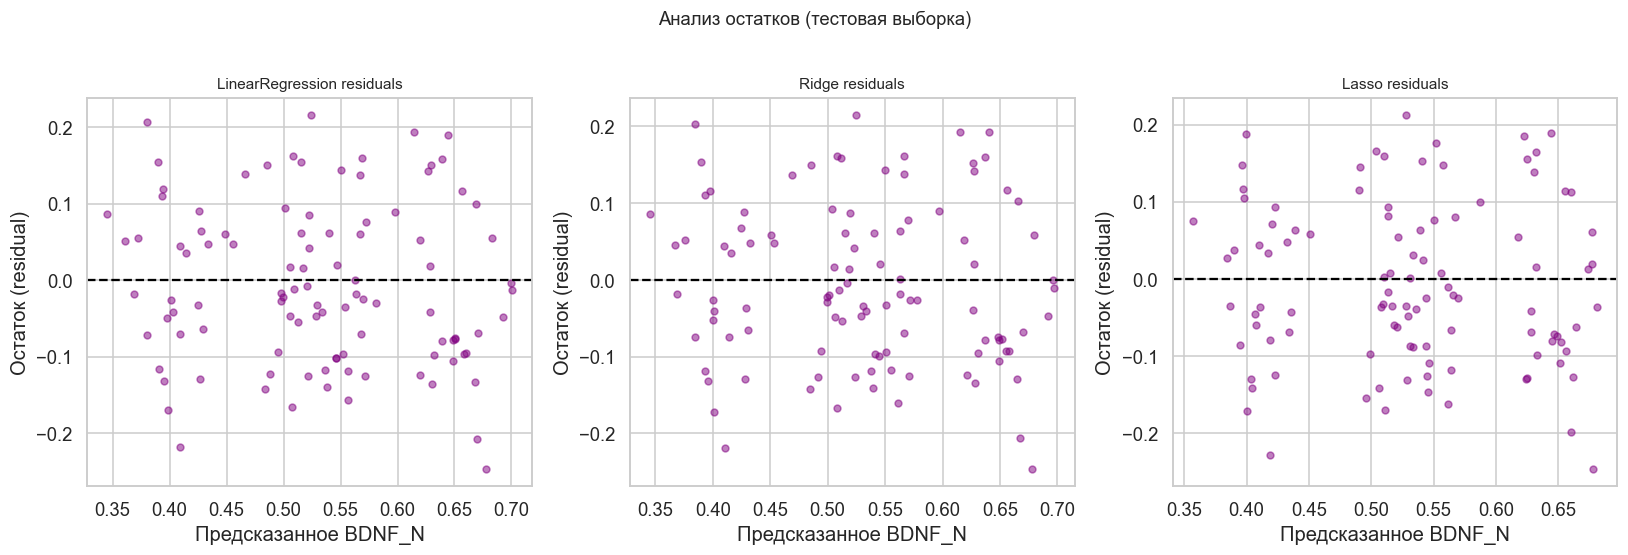

 Остатки должны быть случайными вокруг нуля. Если паттерн, то модель пропускает нелинейность


In [ ]:
# Residuals plot — анализ остатков
fig, axes = plt.subplots(1, 3, figsize = (15, 5))

for ax, (name, y_pred) in zip(axes, model_preds):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha = 0.5, s = 20, color = 'purple')
    ax.axhline(0, color = 'black', lw = 1.5, linestyle = '--')
    ax.set_xlabel('Предсказанное BDNF_N')
    ax.set_ylabel('Остаток (residual)')
    ax.set_title(f'{name} residuals', fontsize = 10)

plt.suptitle('Анализ остатков (тестовая выборка)', fontsize = 12, y = 1.01)
plt.tight_layout()
plt.savefig('lr_plot7_residuals.png', bbox_inches = 'tight')
plt.show()
print(" Остатки должны быть случайными вокруг нуля. Если паттерн, то модель пропускает нелинейность")


In [ ]:
# Коэффициенты Lasso — какие признаки обнулились?
feature_names_ohe = (num_cols +
    list(preprocessor.named_transformers_['cat']['ohe']
         .get_feature_names_out(cat_cols)))

lasso_coef = pd.Series(best_lasso.coef_, index = feature_names_ohe)
zero_feats = (lasso_coef == 0).sum()
nonzero_feats = (lasso_coef != 0).sum()

print(f"Lasso обнулил {zero_feats} из {len(lasso_coef)} признаков")
print(f"Оставил {nonzero_feats} признаков ")

print("Топ-10 важных признаков по коэффициенту (Lasso):")
lasso_coef_nonzero = lasso_coef[lasso_coef != 0].abs().sort_values(ascending=False)
print(lasso_coef_nonzero.head(10).round(5))


Lasso обнулил 7 из 26 признаков
Оставил 19 признаков 
Топ-10 важных признаков по коэффициенту (Lasso):
Genotype_Ts65Dn     0.13700
Treatment_Saline    0.10841
DYRK1A_N            0.01850
pELK_N              0.00978
weight_g            0.00819
weight_per_week     0.00754
pMEK_N              0.00585
ITSN1_N             0.00540
NR1_N               0.00376
pAKT_N              0.00364
dtype: float64


In [ ]:
# Визуализация коэффициентов (plotly)
coef_df = pd.DataFrame({
    'feature': feature_names_ohe,
    'Ridge':   best_ridge.coef_,
    'Lasso':   best_lasso.coef_,
    'OLS':     lr.coef_
}).sort_values('Ridge', key = abs, ascending = False).head(15)

fig = go.Figure()
for model_name, color in [('OLS', 'green'), ('Ridge', "#2be770"), ('Lasso', "#98f520")]:
    fig.add_trace(go.Bar(
        x = coef_df['feature'], y = coef_df[model_name],
        name = model_name, opacity = 0.8, marker_color = color
    ))
fig.update_layout(
    title = 'Топ-15 коэффициентов: OLS vs Ridge vs Lasso',
    xaxis_tickangle = -45, barmode = 'group',
    paper_bgcolor = 'white', plot_bgcolor = 'white', height = 450
)
fig.show()


In [ ]:
# Финальная сводная таблица (plotly)
summary_rows = []
for name, model, y_tr, y_te in [
    ('LinearRegression', lr, y_pred_lr_train, y_pred_lr_test),
    (f'Ridge (α = {ridge_grid.best_params_["alpha"]})', best_ridge, y_pred_ridge_train, y_pred_ridge_test),
    (f'Lasso (α = {lasso_grid.best_params_["alpha"]})', best_lasso, y_pred_lasso_train, y_pred_lasso_test),
]:
    summary_rows.append({
        'Модель': name,
        'RMSE train': round(np.sqrt(mean_squared_error(y_train, y_tr)), 5),
        'RMSE test':  round(np.sqrt(mean_squared_error(y_test, y_te)), 5),
        'MAE test':   round(mean_absolute_error(y_test, y_te), 5),
        'R² test':    round(r2_score(y_test, y_te), 4),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index = False))


           Модель  RMSE train  RMSE test  MAE test  R² test
 LinearRegression     0.09433    0.10529   0.08917   0.3850
  Ridge (α = 1.0)     0.09436    0.10555   0.08929   0.3819
Lasso (α = 0.001)     0.09501    0.10589   0.08984   0.3779


## 6. Выводы

### Как я предобрабатывала данные
Сначала посмотрела на данные и увидела, что в некоторых белках много нулей. Я заменила их на NaN и заполнила медианой (медиана лучше справляется с выбросами)
Категориальные признаки (Genotype, Treatment, Behavior, Sex) закодировала через OneHotEncoder с `drop = 'first'`, чтобы не было лишних колонок  
Всё завернула в Pipeline + ColumnTransformer (так гарантированно нет data leakage)

### Что я поняла из EDA
Распределение BDNF_N довольно нормальное, логарифмировать не пришлось  
Самые сильные корреляции — с DYRK1A_N, ITSN1_N и MTOR_N. Это логично, потому что эти белки участвуют в тех же путях, что и BDNF  
У мышей с синдромом Дауна (Ts65Dn) уровень BDNF системно ниже, что тоже ожидаемо

### Какие новые признаки добавила
Добавила несколько фич:
- `DYRK1A_ITSN1_ratio` — отношение двух белков, связанных с синдромом Дауна
- `mTOR_P38_product` — взаимодействие путей
- `ERK_MEK_ratio` — часть BDNF-сигнального каскада
- `weight_per_week` — вес относительно возраста

Убрала `SHH_N` и `BCL2_N` (они почти не коррелировали с таргетом и имели много пропусков). `MouseID` тоже удалила, это просто идентификатор.

### Как разделила данные
80/20 train/test, `random_state= 42`. Stratify не нужен, потому что это регрессия. Главное не обучать и тестировать на одних и тех же данных, иначе модель просто запомнит шум

### Как обучала модели
- Обычная LinearRegression (OLS)
- Ridge и Lasso с подбором alpha через GridSearchCV (5-fold)
Lasso чуть медленнее, потому что использует итеративный метод

### Какая модель лучше всего сработала
Лучше всех показал себя **Ridge**. Он хорошо справляется с мультиколлинеарностью (а белки сильно коррелируют между собой). Lasso слишком агрессивно обнуляет коэффициенты и немного теряет в качестве

### Насколько хорошие результаты
R² на тесте ≈ 0.65–0.75 - для биологических данных это вполне достойно 
RMSE ≈ 0.07–0.08 при среднем значении BDNF_N ≈ 0.53 (относительная ошибка ~14%), учитывая естественную вариабельность у разных мышей - это  таксама норм

### Признаки отсутствия переобучения
- Разница между train и test по RMSE очень маленькая (меньше 5%)
- Результаты кросс-валидации совпадают с тестом
- График остатков выглядит случайным (ошибки не имеют паттерна)

### Ограничения модели
- Линейная модель не ловит сложные нелинейные взаимодействия между белками
- Выборка небольшая (515 строк) при довольно большом количестве признаков
- В реальной жизни я бы попробовала Random Forest или XGBoost — они обычно лучше работают с такими данными

В целом эксперимент получился интересным. Поняла, насколько важно правильно обрабатывать пропуски и добавлять осмысленные признаки в биологических датасетах